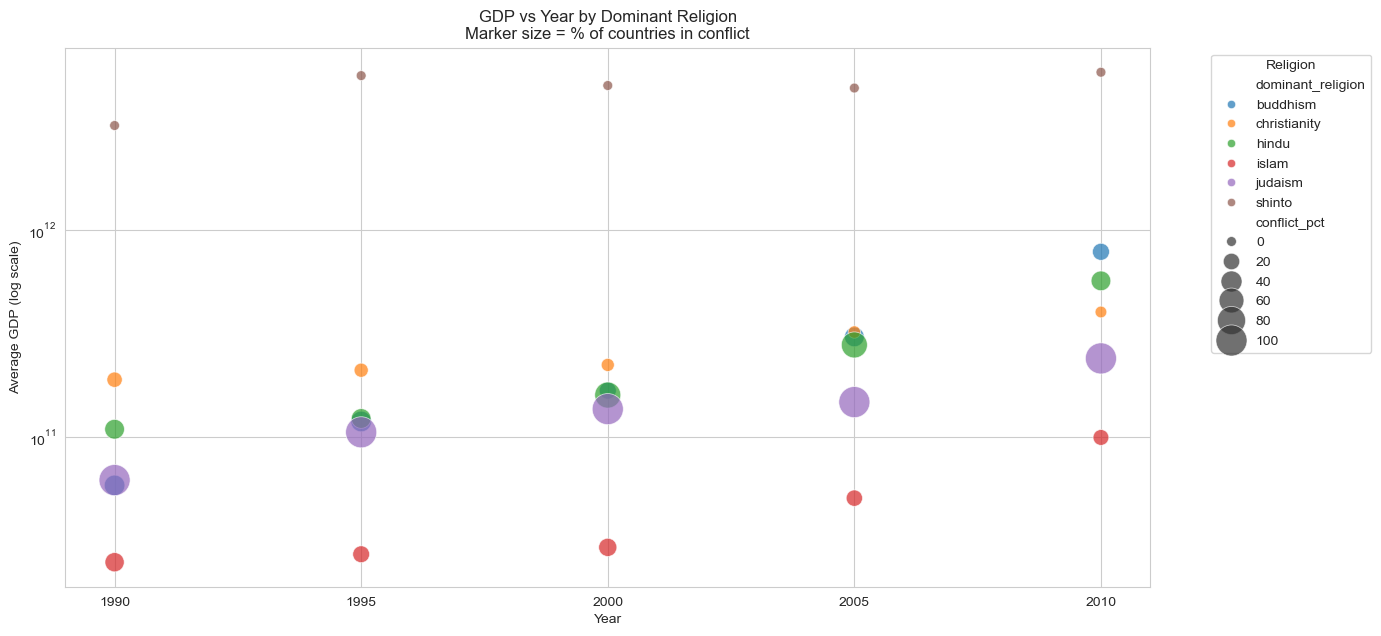

In [225]:
#2
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

# GDP vs year
sns.scatterplot(
    data=agg_df,
    x="year",
    y="avg_gdp",
    hue="dominant_religion",       # color by religion
    size="conflict_pct",           # size by % of countries in conflict
    sizes=(50, 500),               # min/max size of markers
    alpha=0.7
)

plt.yscale("log")

plt.xlabel("Year")
plt.xticks(agg_df['year'].unique())
plt.ylabel("Average GDP (log scale)")
plt.title("GDP vs Year by Dominant Religion\nMarker size = % of countries in conflict")
plt.legend(title="Religion", bbox_to_anchor=(1.05, 1), loc=2) 
plt.show()

**GDP development per religion mirrored by conflict size**

**Insights:**
- Religions with larger conflict bubbles tend to be lower on GDP scale
- Smaller conflict exposure corresponds to higher GDP trajectories
- GDP growth is more strongly linked to conflict exposure than religion and it likely reflects regional geopolitical factors

**Conflicts:** 
- Destroy infrastructure
- Reduce investment
- Reduce labor productivity

In [228]:
#5
import pandas as pd

religion = ["christianity", "judaism", "islam", "buddhism", "hindu", "shinto", "confus_tao"]

# Countries with conflict
conflict_df = df[df["conflict_present"] == 1]

conflict_yearly = conflict_df.groupby("year")[religion].sum()

conflict_pct = conflict_yearly.div(conflict_yearly.sum(axis=1), axis=0) * 100


# Countries without conflict
no_conflict_df = df[df["conflict_present"] == 0]

no_conflict_yearly = no_conflict_df.groupby("year")[religion].sum()

no_conflict_pct = no_conflict_yearly.div(no_conflict_yearly.sum(axis=1), axis=0) * 100

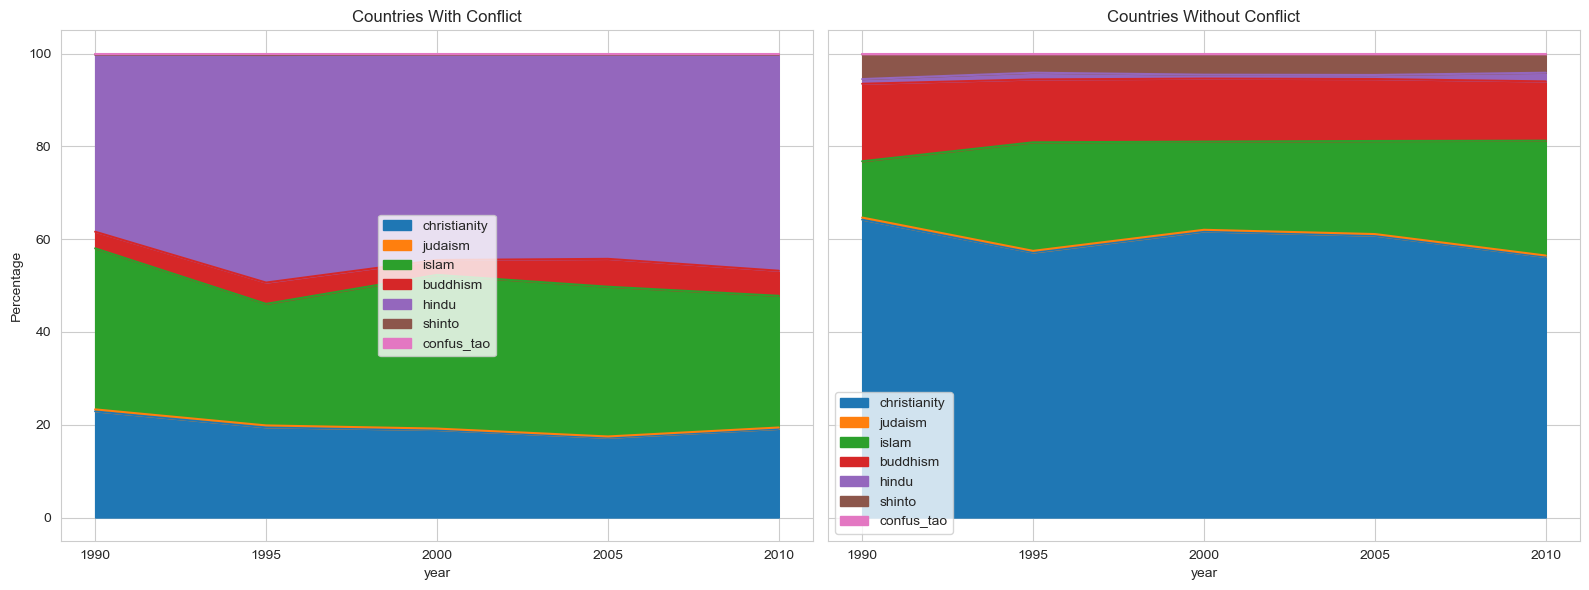

In [232]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Countries with conflict
conflict_pct.plot(kind="area", stacked=True, ax=axes[0])
axes[0].set_title("Countries With Conflict")
axes[0].set_ylabel("Percentage")
axes[0].set_xticks(conflict_pct.index)  # force integer years

# Countries without conflict
no_conflict_pct.plot(kind="area", stacked=True, ax=axes[1])
axes[1].set_title("Countries Without Conflict")
axes[1].set_xticks(no_conflict_pct.index)  # force integer years

plt.tight_layout()
plt.show()

In [230]:
# 6 # Conflict countries
conflict_gdp = df[df["conflict_present"] == 1] \
    .groupby(["year","dominant_religion"])["gdp"] \
    .mean() \
    .reset_index()

# Non-conflict countries
no_conflict_gdp = df[df["conflict_present"] == 0] \
    .groupby(["year","dominant_religion"])["gdp"] \
    .mean() \
    .reset_index()

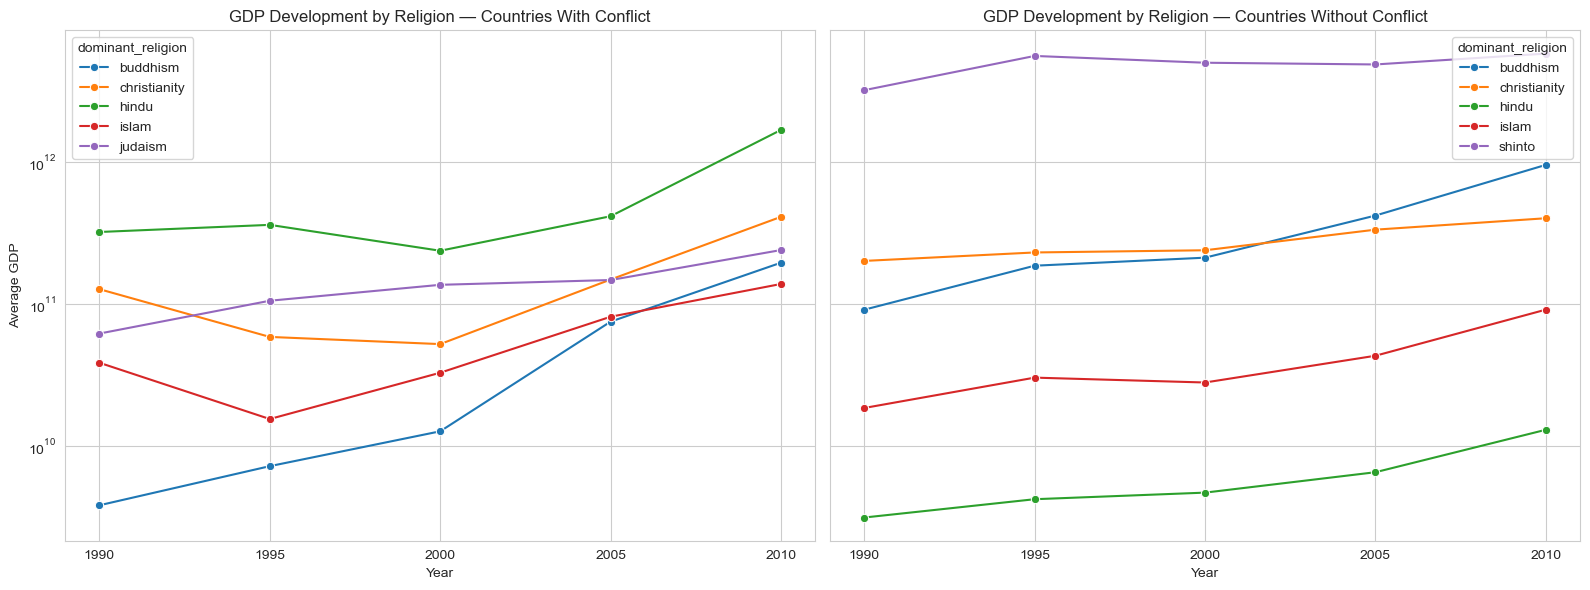

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Conflict countries
sns.lineplot(
    data=conflict_gdp,
    x="year",
    y="gdp",
    hue="dominant_religion",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("GDP Development by Religion — Countries With Conflict")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average GDP")
axes[0].set_yscale("log")
axes[0].set_xticks(conflict_gdp['year'].unique())  # force integer years

# Non-conflict countries
sns.lineplot(
    data=no_conflict_gdp,
    x="year",
    y="gdp",
    hue="dominant_religion",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("GDP Development by Religion — Countries Without Conflict")
axes[1].set_xlabel("Year")
axes[1].set_yscale("log")
axes[1].set_xticks(no_conflict_gdp['year'].unique())  # force integer years

plt.tight_layout()
plt.show()

**Religion share for war involved regions and non-war regions**

**Possible causes in religion fluctuation:**
- Migration / displacement / Population loss. Some religious groups shrink during conflict due to migration or demographic collapse
- Refugee flows often come from specific religious groups
- Regional conflict concentration
- Many conflicts occur in Muslim-majority regions, increasing the representation of Islam in the conflict-country sample

**Conclusion:**
Conflicts correlate with shifts in dominant religion shares, especially toward Islam due to different patterns such as migration and displacement
For instance, while the share of Islamic countries in war is higher, the share of Islam population increases in non-war countries which might be directly influenced by displacement

**GDP development for war involved regions and non-war regions**
GDP development differs substantially between conflict and non-conflict countries. Economies experiencing conflict show more volatile growth patterns and delayed acceleration, while countries without conflict display steady and predictable GDP increases across all religious groups. Although GDP levels vary across religions, these differences appear to reflect regional economic structures rather than religion itself. Conflict exposure therefore emerges as a more important determinant of economic performance than religious composition.

For instance, lower-income economies often grow faster when:
- infrastructure improves
- markets expand
- global trade increases

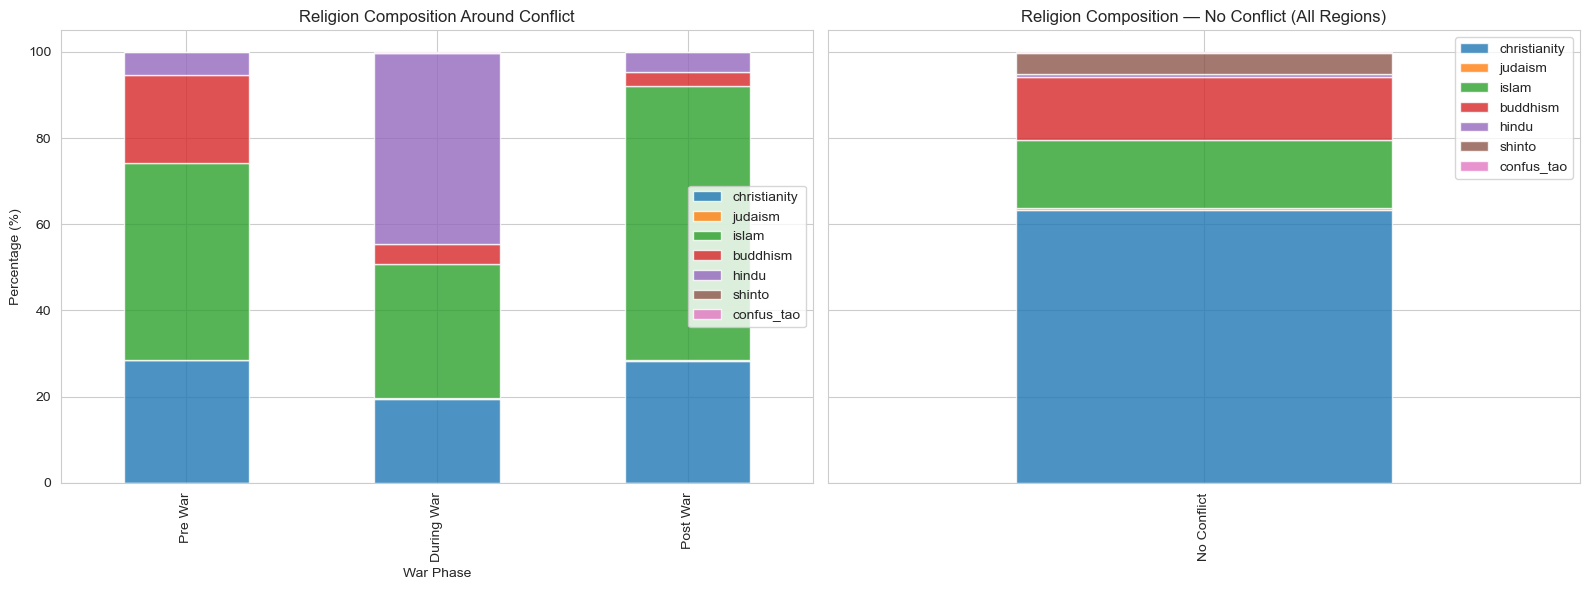

In [158]:
#7
religion = ["christianity", "judaism", "islam", "buddhism", "hindu", "shinto", "confus_tao"]

df["dominant_religion"] = df[religion].idxmax(axis=1)

# Sort by country and year for war phase
df = df.sort_values(["country","year"])
df["conflict_prev"] = df.groupby("country")["conflict_present"].shift(1)
df["conflict_next"] = df.groupby("country")["conflict_present"].shift(-1)

# Define war phases
def war_phase(row):
    if row["conflict_present"] == 1:
        return "During War"
    elif row["conflict_prev"] == 1:
        return "Post War"
    elif row["conflict_next"] == 1:
        return "Pre War"
    else:
        return "No Conflict"

df["war_phase"] = df.apply(war_phase, axis=1)

# Aggregate religion counts per war phase
religion_phase = df.groupby("war_phase")[religion].sum()

religion_phase_pct = religion_phase.div(religion_phase.sum(axis=1), axis=0) * 100

# Separate war phases vs no conflict
war_phases = ["Pre War", "During War", "Post War"]
war_data = religion_phase_pct.loc[war_phases]

# For No Conflict, aggregate all regions together
no_conflict_df = df[df["war_phase"] == "No Conflict"]
no_conflict_sum = no_conflict_df[religion].sum()
no_conflict_pct = (no_conflict_sum / no_conflict_sum.sum()) * 100
no_conflict_data = pd.DataFrame([no_conflict_pct], index=["No Conflict"])

fig, axes = plt.subplots(1,2, figsize=(16,6), sharey=True)

# War phases
war_data.plot(
    kind="bar",
    stacked=True,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title("Religion Composition Around Conflict")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_xlabel("War Phase")

# No conflict (all regions)
no_conflict_data.plot(
    kind="bar",
    stacked=True,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Religion Composition — No Conflict (All Regions)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

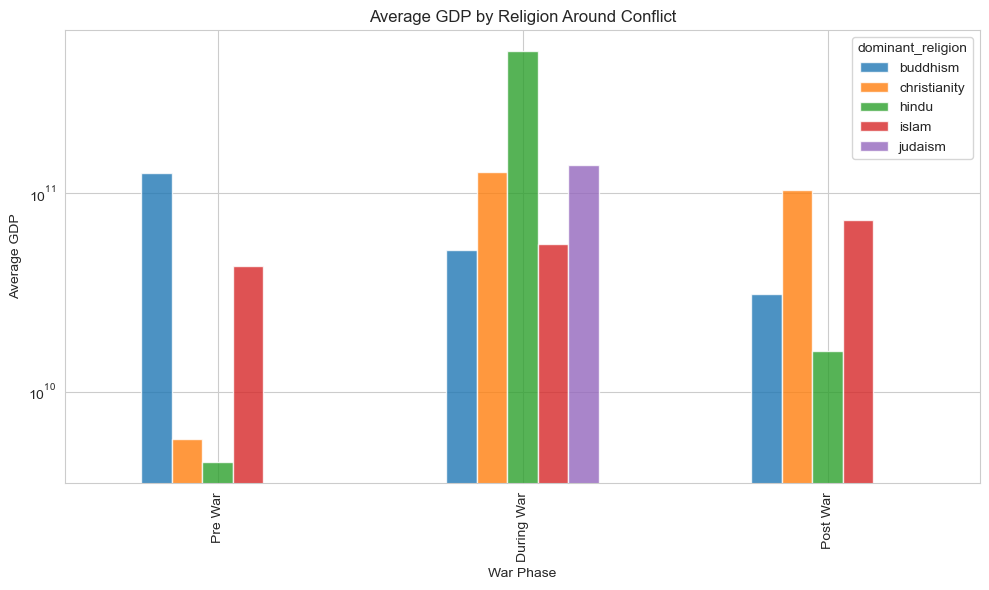

In [166]:
#12
war_df = df[df["war_phase"].isin(["Pre War","During War","Post War"])]

# average GDP by war phase and dominant religion
gdp_phase_religion = (
    war_df.groupby(["war_phase","dominant_religion"])["gdp"]
    .mean()
    .reset_index()
)

# reshape for plotting
gdp_pivot = gdp_phase_religion.pivot(
    index="war_phase",
    columns="dominant_religion",
    values="gdp"
)

# ensure correct order
war_phases = ["Pre War","During War","Post War"]
gdp_pivot = gdp_pivot.reindex(war_phases)

# plot
fig, ax = plt.subplots(figsize=(10,6))

gdp_pivot.plot(
    kind="bar",
    ax=ax,
    alpha=0.8
)

ax.set_title("Average GDP by Religion Around Conflict")
ax.set_ylabel("Average GDP")
ax.set_xlabel("War Phase")

# GDP values vary a lot → log scale helps
ax.set_yscale("log")

plt.tight_layout()
plt.show()

**Conflict countries**
GDP growth exists but is more volatile:
  - Hindu-dominant countries show strong growth
  - Christian countries recover post-war
  - Islam-dominant countries grow slower overall

**Non-conflict countries**
- GDP trends are consistently upward across all religions.
- Conflict weakens GDP growth consistency regardless of religion.

While religious composition in conflict countries shifts significantly between pre-war, during-war, and post-war periods, these changes do not show a consistent correlation with GDP levels. Instead, GDP differences appear to be driven by regional economic structures and the specific countries included in each religious group. Conflict exposure itself plays a more significant role in shaping economic outcomes than religious distribution.

**Important**
Changes in religious share across conflict phases reflect shifts in which regions are experiencing conflict, rather than religion itself driving GDP performance.
GDP differences mainly reflect:
- regional development levels
- country size
- conflict exposure
(This is why we see huge spikes in religion and GDP share for Hindu)

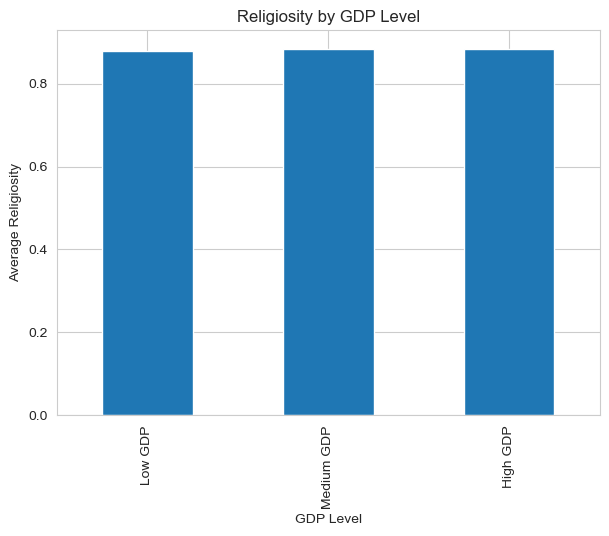

In [171]:
table.reset_index().plot(
    x="gdp_group",
    y="avg_religiosity",
    kind="bar",
    legend=False,
    figsize=(7,5)
)

plt.ylabel("Average Religiosity")
plt.xlabel("GDP Level")
plt.title("Religiosity by GDP Level")

plt.show()

**Final conclusion**

Religion does not strongly determine economic growth and there is no strong correlation between GDP level and religiosity.

**Instead:**
Conflict -> demographic shifts -> economic disruption

**Religion mainly appears because:**
- conflicts cluster geographically
- certain regions share dominant religions

**The real relationship**
Geography -> Religion distribution
Geography -> Conflict probability
Conflict -> GDP slowdown
Conflict -> demographic changes

The analysis suggests that conflict influences religious composition indirectly through demographic shocks such as migration and population displacement. Countries experiencing conflict show greater fluctuations in religious distribution compared to peaceful regions. However, GDP growth patterns appear more strongly associated with conflict exposure than with dominant religion. While religion correlates with economic developemnt due to geographic clustering, conflict intensity is the primary factor explaining variations in GDP growth.